In [1]:
PARTITION_FIT_DATA = "id"

# Ensemble of partitions

**Partitioning schemas:**
1. *Quantile binning* by each feature
2. *KMeans* by random feature subset
3. *Decision Tree* by random labels (0 / 1) several times

**Quality:**
- ROC-AUC, PR-AUC
- Accuracy, Precision, Recall, F1
- TPR@FPR: 0.01, 0.05, 0.1

**Visualization:**
- ROC-curves
- Precision-Recall curves
- OOD-score distribution
- Confusion matrix

In [2]:
import sys
sys.path.insert(0, '..')

from point_wise_detection.partition_ood import (
    load_dataset,
    describe_dataset,
    full_pipeline,
    DATASETS,
    ALL_META_FEATURES,
    DEFAULT_META_FEATURES,
)

import pandas as pd
import numpy as np

## Hyperparameters

In [3]:
N_BINS = 10
N_KMEANS_CLUSTERS = 10
N_TREE_PARTITIONS = 5
TREE_MAX_DEPTH = 3
TEST_SIZE = 0.3
RANDOM_STATE = 42
USE_RAW_FEATURES = True
CV_FOLDS = 5
BALANCE_STRATEGY = 'oversample'
INCLUDE_MLP = True

TAXONOMY_META_FEATURES = [
    'dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood',
    'local_outlier_factor_score', 'knn_distance_k',
    'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm',
    'iqr_norm', 'trimmed_mean_norm',
    'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std',
    'marginal_kl_to_reference_mean', 'quantile_surprisal_mean',
    'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation',
    'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs',
    'covariance_condition_number',
    'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation',
    'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean',
    'log_count', 'density', 'out_of_range_count', 'n_beyond_2std',
    'partition_agreement_count', 'leaf_depth',
]
META_FEATURES = TAXONOMY_META_FEATURES
META_FEATURES

['dist_to_mean',
 'normalized_dist',
 'cosine_dist',
 'dist_to_median',
 'log_likelihood',
 'local_outlier_factor_score',
 'knn_distance_k',
 'mean_norm',
 'std_norm',
 'skew_norm',
 'kurtosis_norm',
 'median_abs_deviation_norm',
 'iqr_norm',
 'trimmed_mean_norm',
 'cell_entropy',
 'marginal_entropy_mean',
 'marginal_entropy_std',
 'marginal_kl_to_reference_mean',
 'quantile_surprisal_mean',
 'mahalanobis',
 'covariance_trace',
 'covariance_logdet',
 'mean_abs_correlation',
 'pairwise_pearson_corr_mean_abs',
 'pairwise_spearman_corr_mean_abs',
 'covariance_condition_number',
 'pairwise_mutual_info_mean',
 'pairwise_mutual_info_max',
 'total_correlation',
 'joint_entropy_pairwise_mean',
 'pairwise_js_divergence_mean',
 'log_count',
 'density',
 'out_of_range_count',
 'n_beyond_2std',
 'partition_agreement_count',
 'leaf_depth']

In [4]:
summary_rows = []

---

## Taxi Data

In [5]:
ID_data, OOD_data = load_dataset('Taxi')
describe_dataset(ID_data, OOD_data)

ID data shape:      (10000, 6)
OOD data shape:     (10000, 6)
Number of features: 6


DATASET: Taxi
ID data shape:      (10000, 6)
OOD data shape:     (10000, 6)
Number of features: 6

BUILDING PARTITION REPRESENTATION
Use raw features: True
Partition fit data: id
Balance strategy: oversample
CV folds: 5
Meta features (37): ['dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood', 'local_outlier_factor_score', 'knn_distance_k', 'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm', 'iqr_norm', 'trimmed_mean_norm', 'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std', 'marginal_kl_to_reference_mean', 'quantile_surprisal_mean', 'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation', 'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs', 'covariance_condition_number', 'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation', 'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean', 'log_count', 'density', 'out_of_range_count', 'n_beyond_2std', 

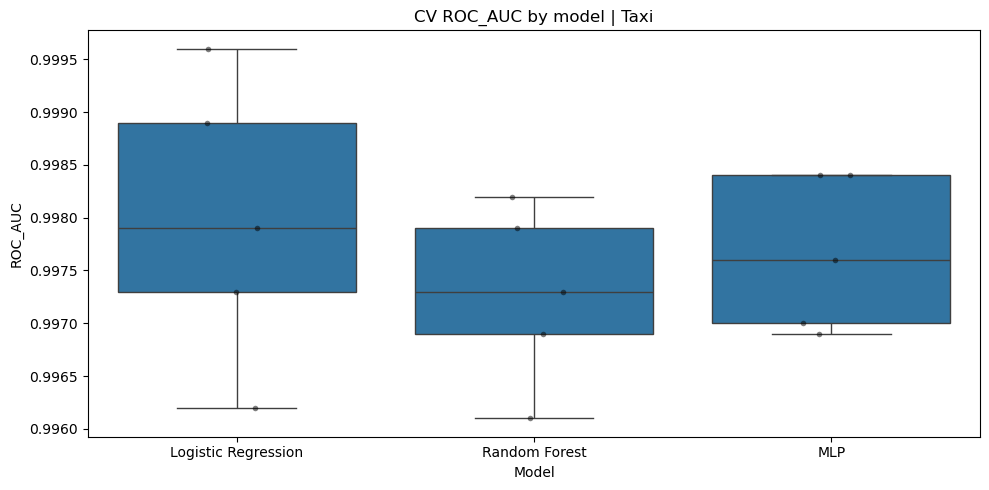

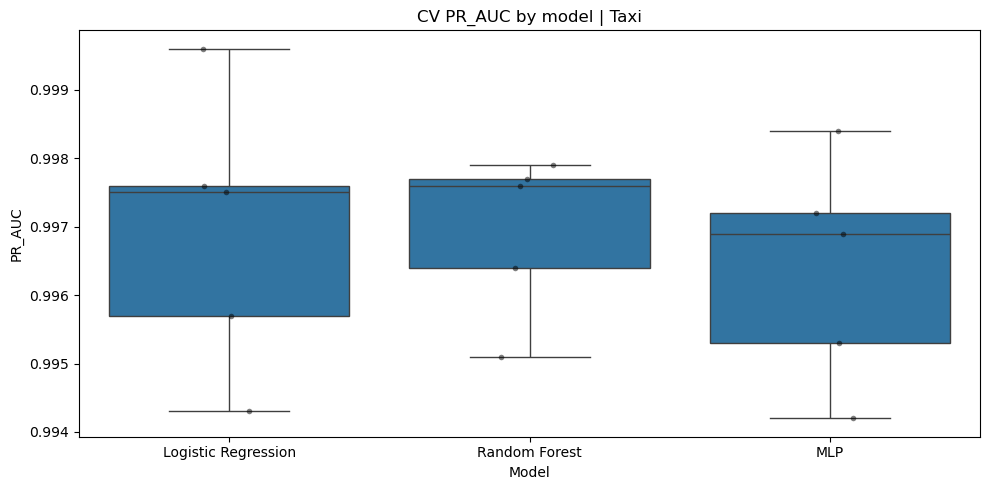

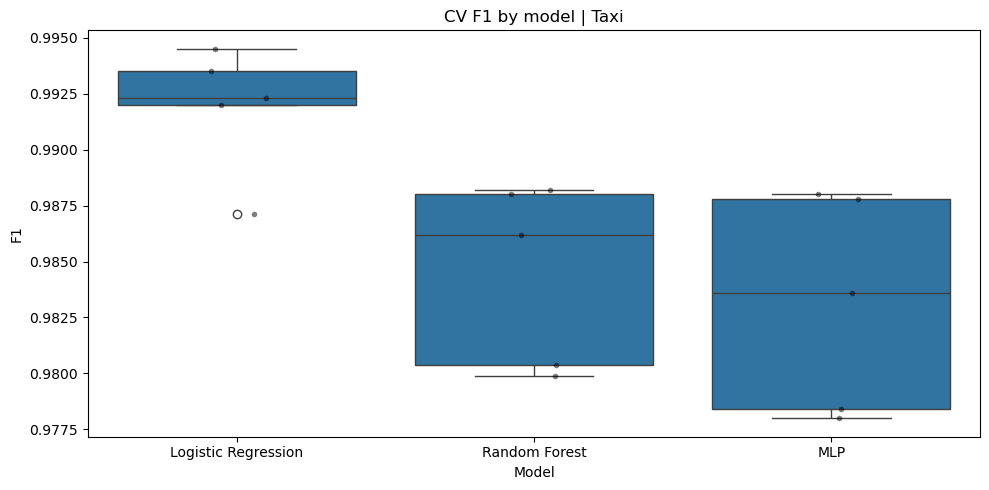


CV MEAN ROC CURVES


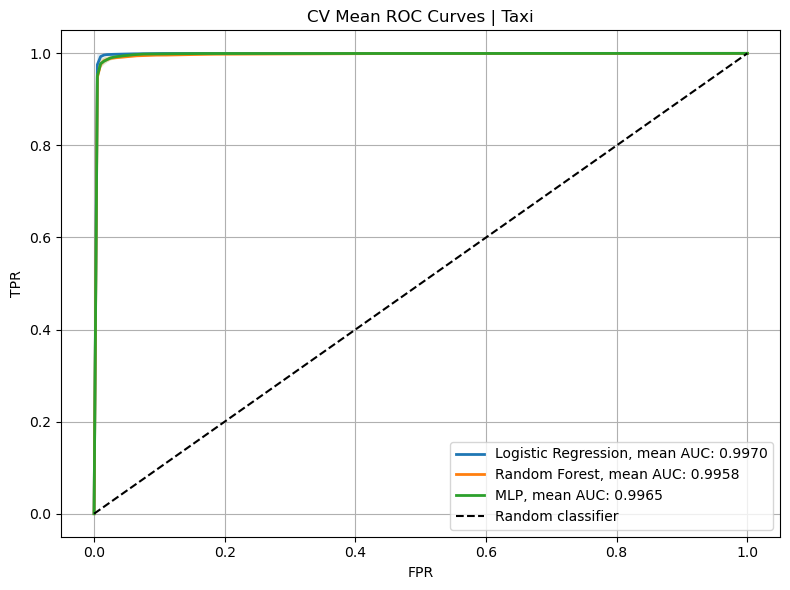

In [6]:
res_taxi = full_pipeline(
    ID_data, OOD_data,
    dataset_name='Taxi',
    test_size=TEST_SIZE,
    n_bins=N_BINS,
    n_kmeans_clusters=N_KMEANS_CLUSTERS,
    n_tree_partitions=N_TREE_PARTITIONS,
    tree_max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
    use_raw_features=USE_RAW_FEATURES,
    meta_features=META_FEATURES,
    cv_folds=CV_FOLDS,
    balance_strategy=BALANCE_STRATEGY,
    include_mlp=INCLUDE_MLP,
)
summary_rows.append(('Taxi', res_taxi['results_df']))

---
## Electricity Data

In [7]:
ID_data, OOD_data = load_dataset('Electricity')
describe_dataset(ID_data, OOD_data)

ID data shape:      (9986, 6)
OOD data shape:     (10014, 6)
Number of features: 6


DATASET: Electricity
ID data shape:      (9986, 6)
OOD data shape:     (10014, 6)
Number of features: 6

BUILDING PARTITION REPRESENTATION
Use raw features: True
Partition fit data: id
Balance strategy: oversample
CV folds: 5
Meta features (37): ['dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood', 'local_outlier_factor_score', 'knn_distance_k', 'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm', 'iqr_norm', 'trimmed_mean_norm', 'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std', 'marginal_kl_to_reference_mean', 'quantile_surprisal_mean', 'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation', 'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs', 'covariance_condition_number', 'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation', 'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean', 'log_count', 'density', 'out_of_range_count', 'n_beyond_2

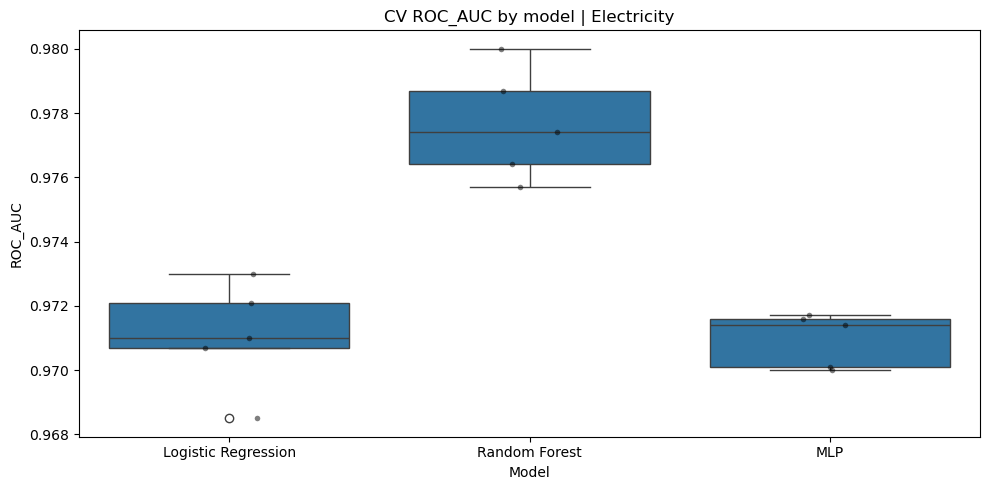

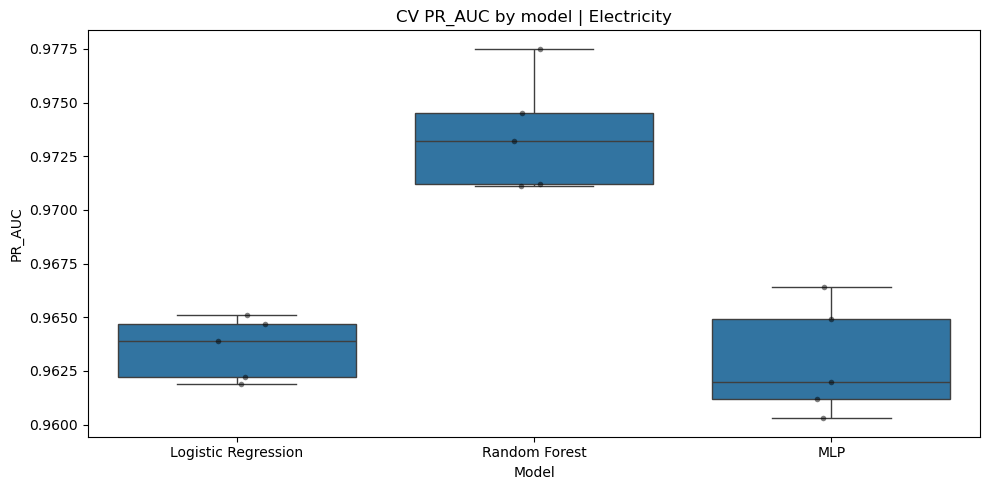

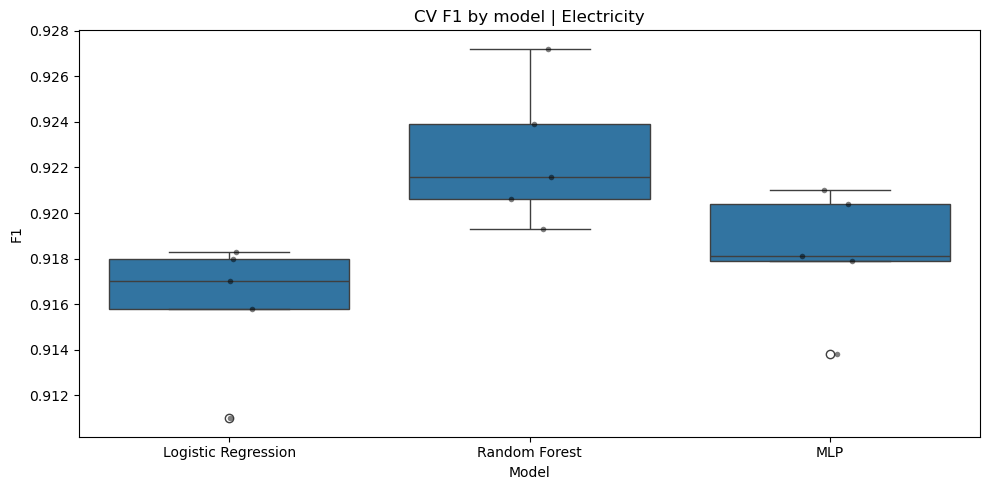


CV MEAN ROC CURVES


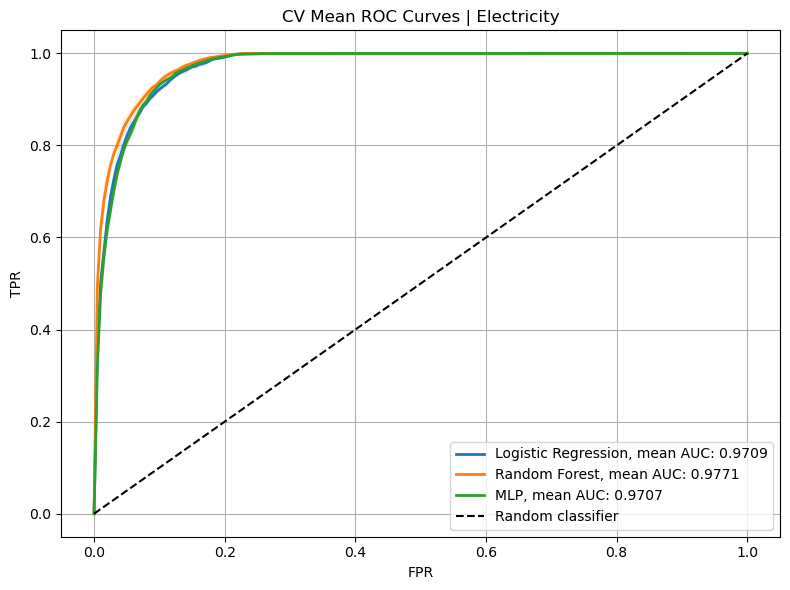

In [8]:
res_electricity = full_pipeline(
    ID_data, OOD_data,
    dataset_name='Electricity',
    test_size=TEST_SIZE,
    n_bins=N_BINS,
    n_kmeans_clusters=N_KMEANS_CLUSTERS,
    n_tree_partitions=N_TREE_PARTITIONS,
    tree_max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
    use_raw_features=USE_RAW_FEATURES,
    meta_features=META_FEATURES,
    cv_folds=CV_FOLDS,
    balance_strategy=BALANCE_STRATEGY,
    include_mlp=INCLUDE_MLP,
)
summary_rows.append(('Electricity', res_electricity['results_df']))

---
## Income Data

In [9]:
ID_data, OOD_data = load_dataset('Income')
describe_dataset(ID_data, OOD_data)

ID data shape:      (20380, 12)
OOD data shape:     (9782, 12)
Number of features: 12


DATASET: Income
ID data shape:      (20380, 12)
OOD data shape:     (9782, 12)
Number of features: 12

BUILDING PARTITION REPRESENTATION
Use raw features: True
Partition fit data: id
Balance strategy: oversample
CV folds: 5
Meta features (37): ['dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood', 'local_outlier_factor_score', 'knn_distance_k', 'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm', 'iqr_norm', 'trimmed_mean_norm', 'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std', 'marginal_kl_to_reference_mean', 'quantile_surprisal_mean', 'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation', 'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs', 'covariance_condition_number', 'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation', 'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean', 'log_count', 'density', 'out_of_range_count', 'n_beyond_2st

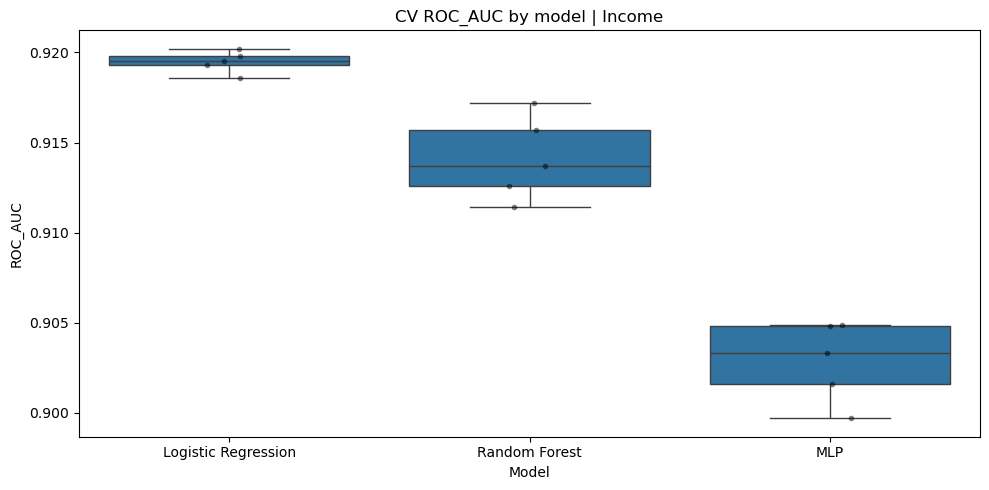

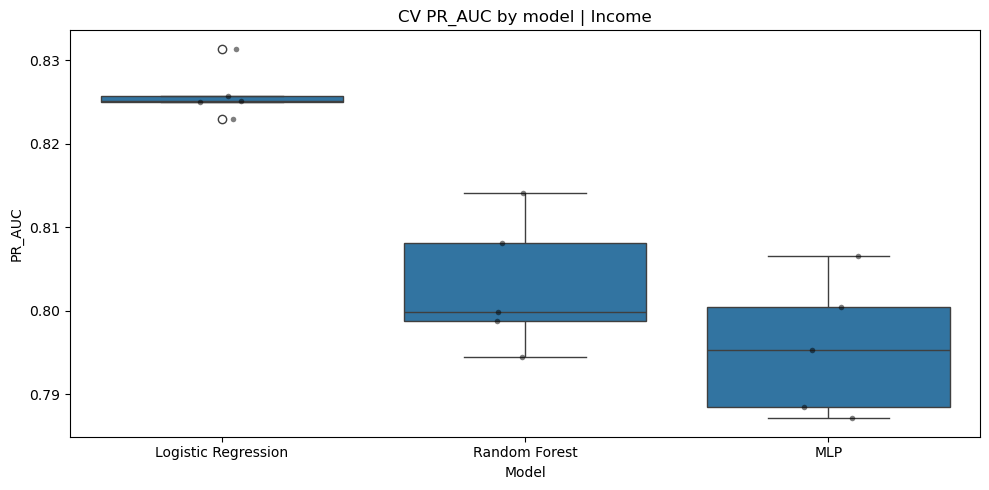

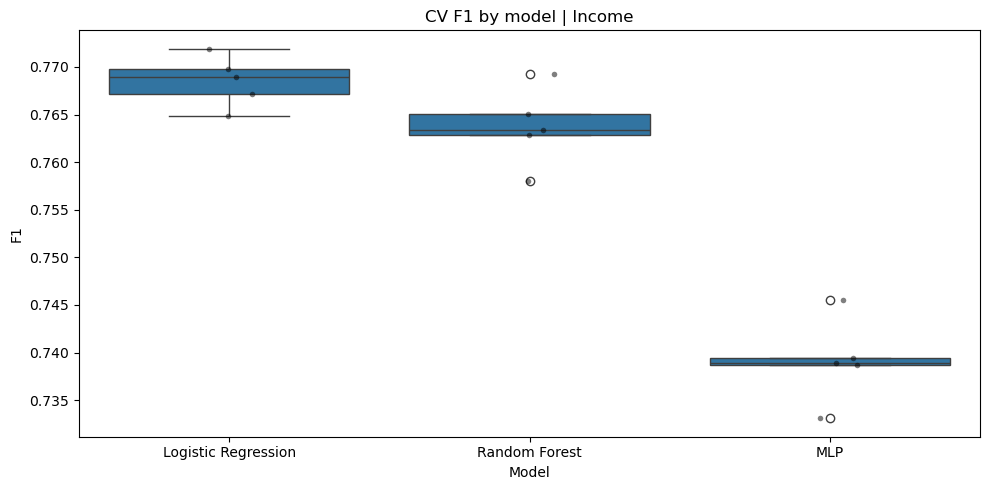


CV MEAN ROC CURVES


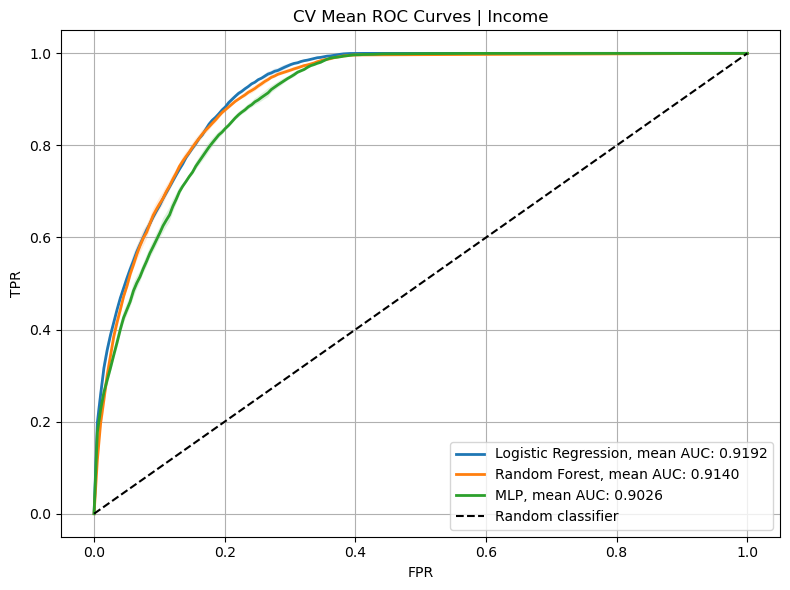

In [10]:
res_income = full_pipeline(
    ID_data, OOD_data,
    dataset_name='Income',
    test_size=TEST_SIZE,
    n_bins=N_BINS,
    n_kmeans_clusters=N_KMEANS_CLUSTERS,
    n_tree_partitions=N_TREE_PARTITIONS,
    tree_max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
    use_raw_features=USE_RAW_FEATURES,
    meta_features=META_FEATURES,
    cv_folds=CV_FOLDS,
    balance_strategy=BALANCE_STRATEGY,
    include_mlp=INCLUDE_MLP,
)
summary_rows.append(('Income', res_income['results_df']))

---
## MVx6 Data

In [11]:
ID_data, OOD_data = load_dataset('MVx6')
describe_dataset(ID_data, OOD_data)

ID data shape:      (20384, 9)
OOD data shape:     (20384, 9)
Number of features: 9


DATASET: MVx6
ID data shape:      (20384, 9)
OOD data shape:     (20384, 9)
Number of features: 9

BUILDING PARTITION REPRESENTATION
Use raw features: True
Partition fit data: id
Balance strategy: oversample
CV folds: 5
Meta features (37): ['dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood', 'local_outlier_factor_score', 'knn_distance_k', 'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm', 'iqr_norm', 'trimmed_mean_norm', 'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std', 'marginal_kl_to_reference_mean', 'quantile_surprisal_mean', 'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation', 'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs', 'covariance_condition_number', 'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation', 'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean', 'log_count', 'density', 'out_of_range_count', 'n_beyond_2std', 

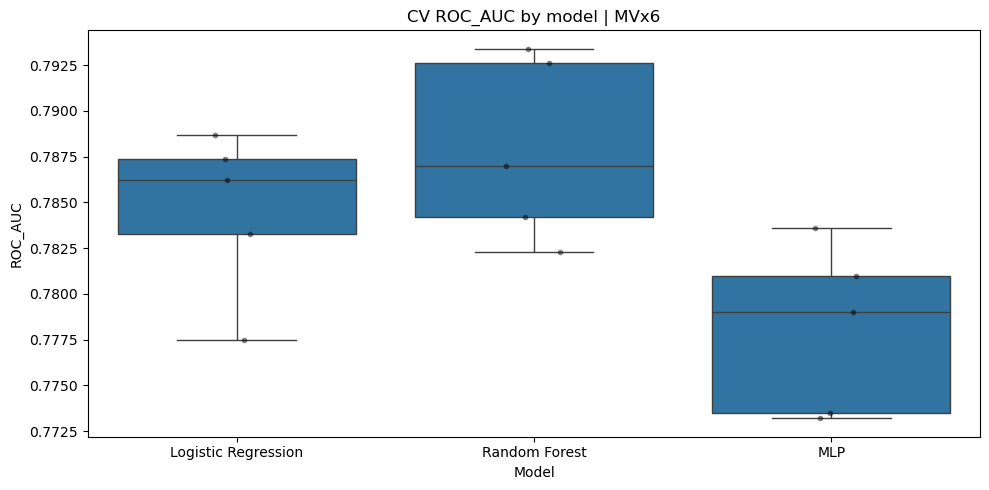

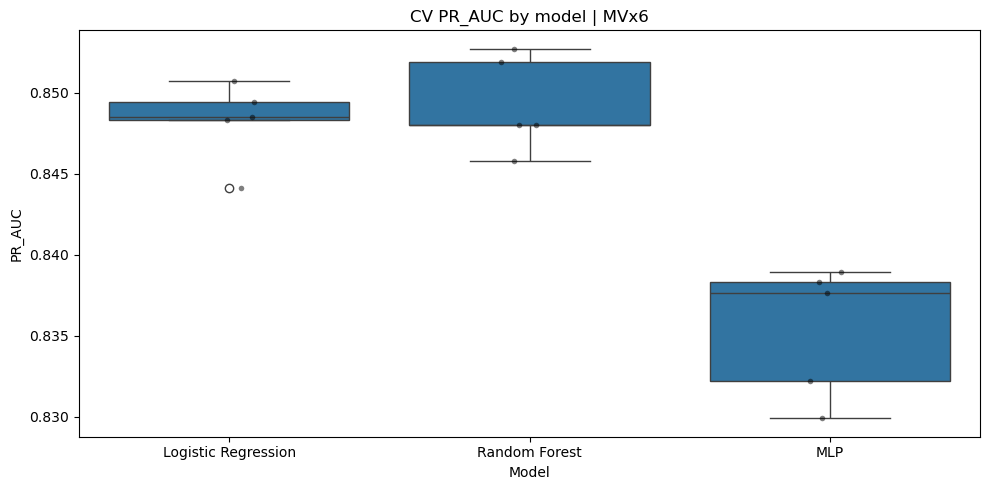

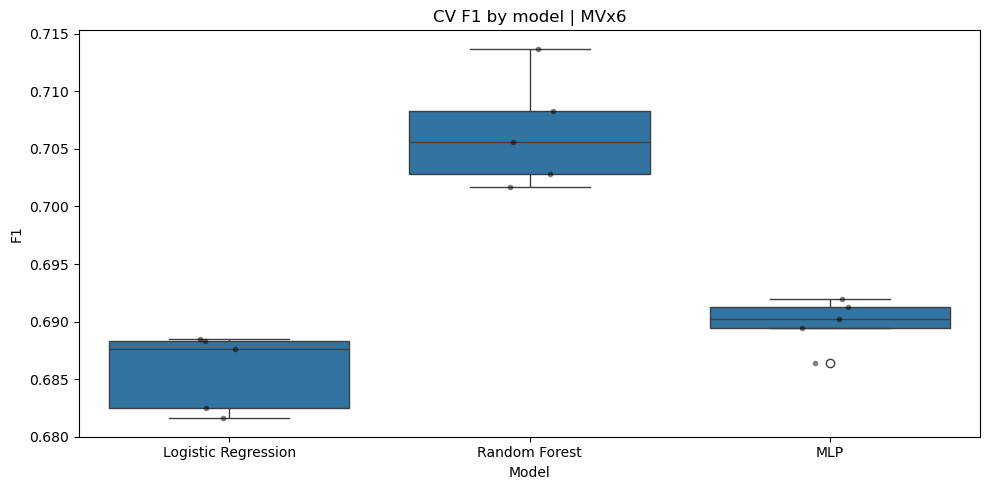


CV MEAN ROC CURVES


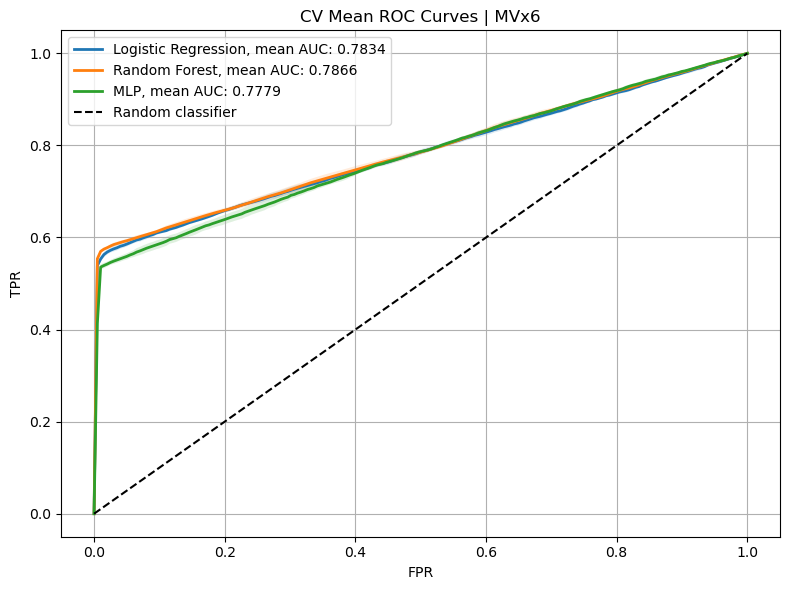

In [12]:
res_mvx6 = full_pipeline(
    ID_data, OOD_data,
    dataset_name='MVx6',
    test_size=TEST_SIZE,
    n_bins=N_BINS,
    n_kmeans_clusters=N_KMEANS_CLUSTERS,
    n_tree_partitions=N_TREE_PARTITIONS,
    tree_max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
    use_raw_features=USE_RAW_FEATURES,
    meta_features=META_FEATURES,
    cv_folds=CV_FOLDS,
    balance_strategy=BALANCE_STRATEGY,
    include_mlp=INCLUDE_MLP,
)
summary_rows.append(('MVx6', res_mvx6['results_df']))

---
## Diabetes Data

In [13]:
ID_data, OOD_data = load_dataset('Diabetes')
describe_dataset(ID_data, OOD_data)

ID data shape:      (34288, 183)
OOD data shape:     (1500, 183)
Number of features: 183


In [ ]:
res_diabetes = full_pipeline(
    ID_data, OOD_data,
    dataset_name='Diabetes',
    test_size=TEST_SIZE,
    n_bins=N_BINS,
    n_kmeans_clusters=N_KMEANS_CLUSTERS,
    n_tree_partitions=N_TREE_PARTITIONS,
    tree_max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
    use_raw_features=USE_RAW_FEATURES,
    meta_features=META_FEATURES,
    cv_folds=CV_FOLDS,
    balance_strategy=BALANCE_STRATEGY,
    include_mlp=INCLUDE_MLP,
)
summary_rows.append(('Diabetes', res_diabetes['results_df']))

DATASET: Diabetes
ID data shape:      (34288, 183)
OOD data shape:     (1500, 183)
Number of features: 183

BUILDING PARTITION REPRESENTATION
Use raw features: True
Partition fit data: id
Balance strategy: oversample
CV folds: 5
Meta features (37): ['dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood', 'local_outlier_factor_score', 'knn_distance_k', 'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm', 'iqr_norm', 'trimmed_mean_norm', 'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std', 'marginal_kl_to_reference_mean', 'quantile_surprisal_mean', 'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation', 'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs', 'covariance_condition_number', 'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation', 'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean', 'log_count', 'density', 'out_of_range_count', 'n_beyon

---
## California Data

In [ ]:
ID_data, OOD_data = load_dataset('California')
describe_dataset(ID_data, OOD_data)

ID data shape:      (10315, 7)
OOD data shape:     (10319, 7)
Number of features: 7


DATASET: California
ID data shape:      (10315, 7)
OOD data shape:     (10319, 7)
Number of features: 7

BUILDING PARTITION REPRESENTATION
Use raw features: True
Meta features (10): ['log_count', 'density', 'mean_norm', 'std_norm', 'dist_to_mean', 'mean_radius', 'max_radius', 'cell_entropy', 'skew_norm', 'kurtosis_norm']
Number of partitioning schemes: 15
Representation dimension:       157
Train set: 14443 samples (ID: 7220, OOD: 7223)
Test set:  6191 samples (ID: 3095, OOD: 3096)

CLASSIFICATION RESULTS
                     roc-auc  pr-auc  accuracy  precision  recall  f1-score
Logistic Regression   0.9963  0.9947    0.9683     0.9495  0.9893    0.9690
Random Forest         0.9968  0.9965    0.9735     0.9607  0.9874    0.9739

TPR @ FPR
                       0.01    0.05    0.10
Logistic Regression  0.9590  0.9890  0.9984
Random Forest        0.9225  0.9893  0.9987

ROC CURVES


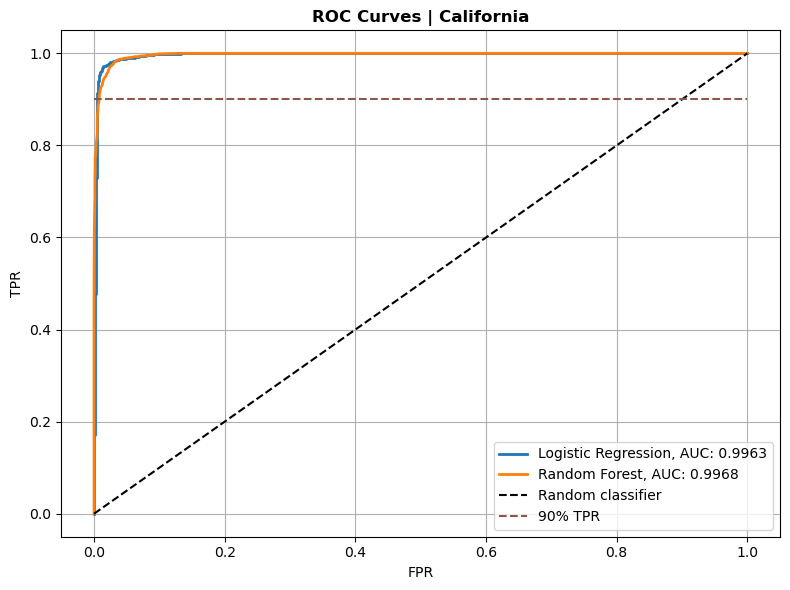


PRECISION-RECALL CURVES


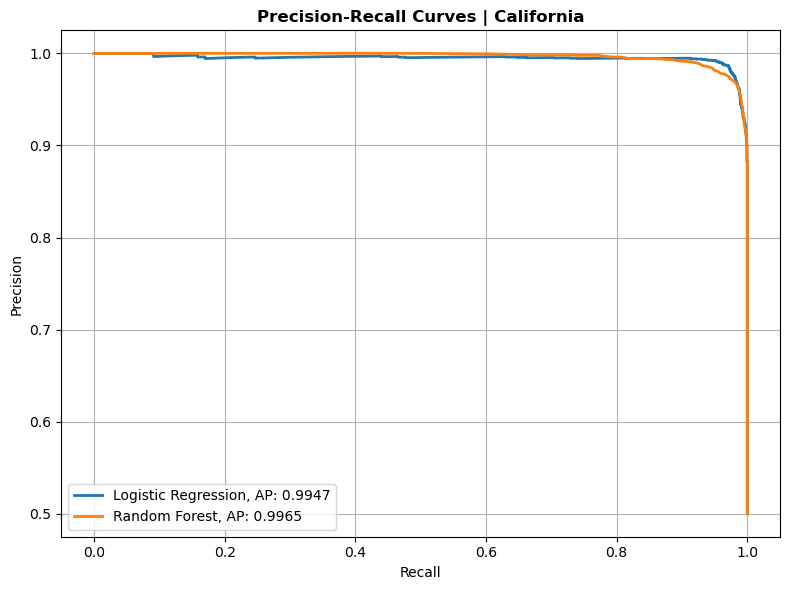


SCORE DISTRIBUTIONS


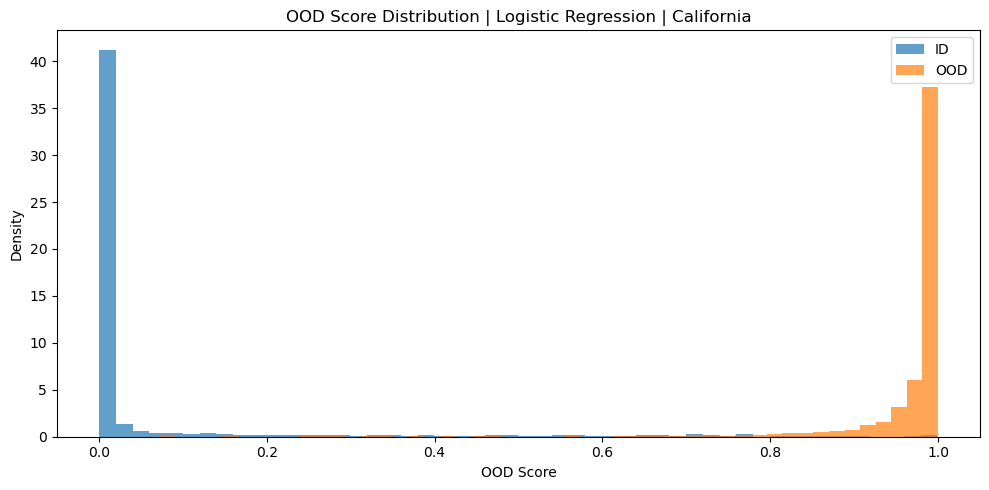

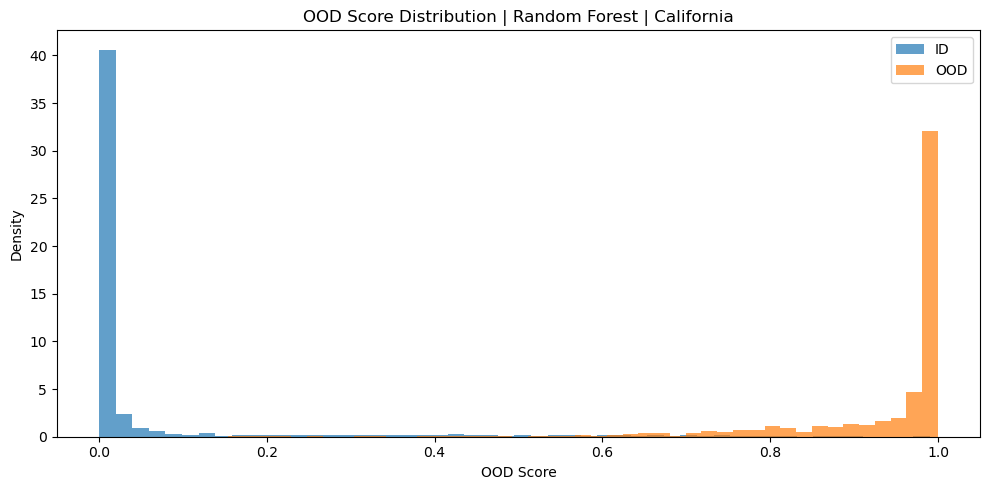


CONFUSION MATRICES


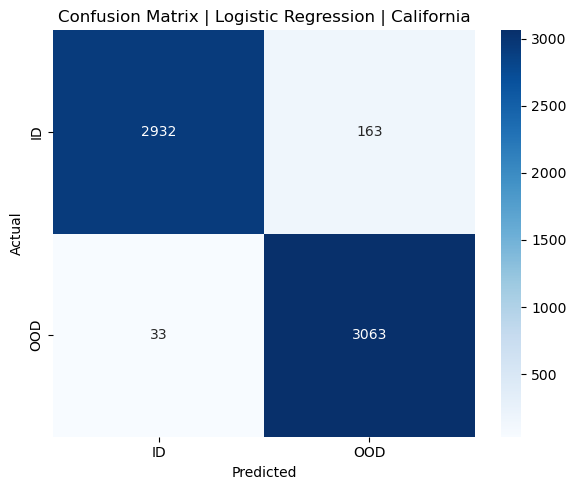

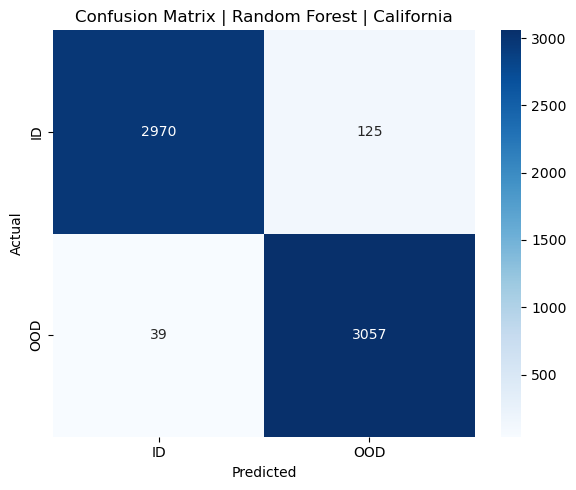

In [ ]:
res_california = full_pipeline(
    ID_data, OOD_data,
    dataset_name='California',
    test_size=TEST_SIZE,
    n_bins=N_BINS,
    n_kmeans_clusters=N_KMEANS_CLUSTERS,
    n_tree_partitions=N_TREE_PARTITIONS,
    tree_max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
    use_raw_features=USE_RAW_FEATURES,
    meta_features=META_FEATURES,
    cv_folds=CV_FOLDS,
    balance_strategy=BALANCE_STRATEGY,
    include_mlp=INCLUDE_MLP,
)
summary_rows.append(('California', res_california['results_df']))

---
## ACS Accidents Data

In [ ]:
ID_data, OOD_data = load_dataset('ACS Accidents')
describe_dataset(ID_data, OOD_data)

ID data shape:      (22653, 45)
OOD data shape:     (3955, 45)
Number of features: 45


DATASET: ACS Accidents
ID data shape:      (22653, 45)
OOD data shape:     (3955, 45)
Number of features: 45

BUILDING PARTITION REPRESENTATION
Use raw features: True
Meta features (10): ['log_count', 'density', 'mean_norm', 'std_norm', 'dist_to_mean', 'mean_radius', 'max_radius', 'cell_entropy', 'skew_norm', 'kurtosis_norm']
Number of partitioning schemes: 72
Representation dimension:       765
Train set: 18625 samples (ID: 15857, OOD: 2768)
Test set:  7983 samples (ID: 6796, OOD: 1187)

CLASSIFICATION RESULTS
                     roc-auc  pr-auc  accuracy  precision  recall  f1-score
Logistic Regression    0.999  0.9967    0.9959      0.994  0.9781     0.986
Random Forest          1.000  1.0000    1.0000      1.000  1.0000     1.000

TPR @ FPR
                       0.01    0.05    0.10
Logistic Regression  0.9966  0.9966  0.9983
Random Forest        1.0000  1.0000  1.0000

ROC CURVES


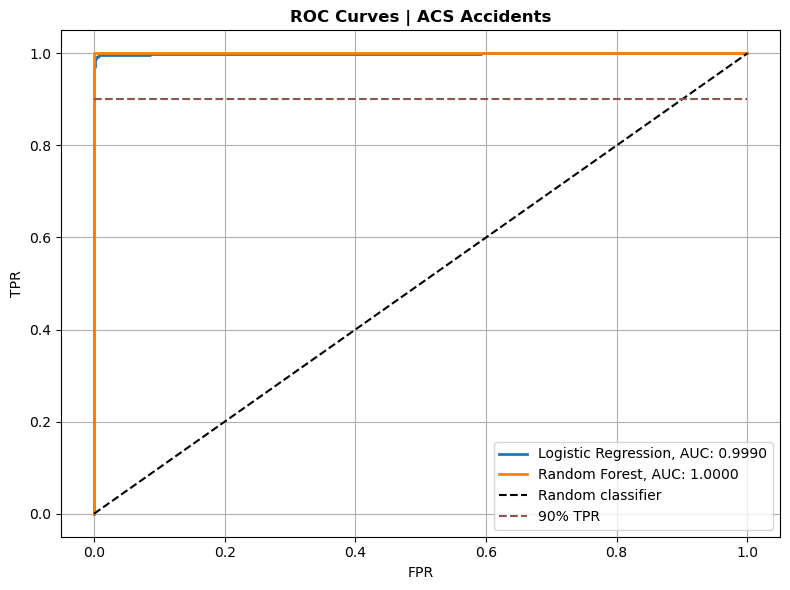


PRECISION-RECALL CURVES


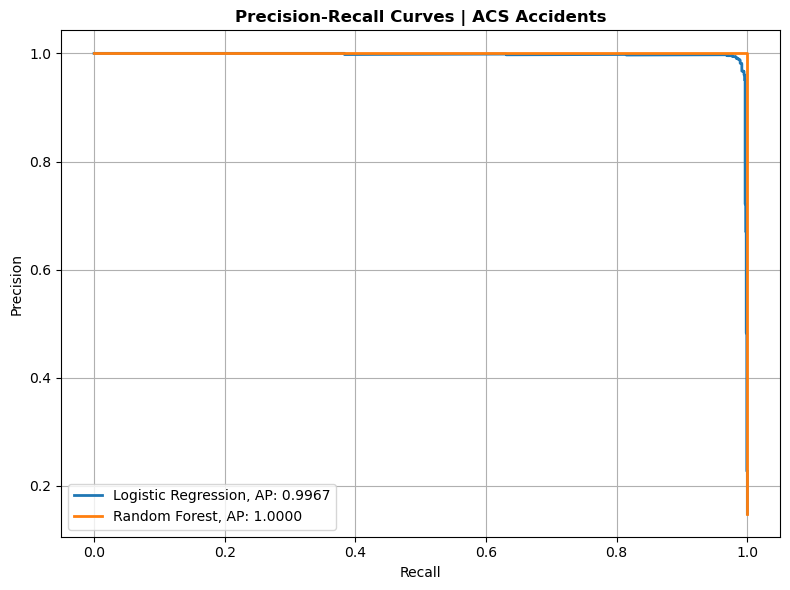


SCORE DISTRIBUTIONS


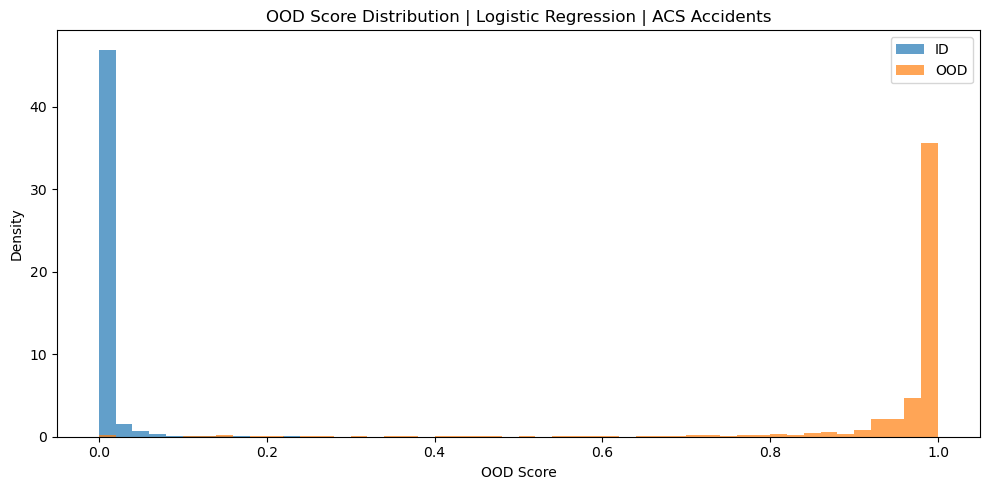

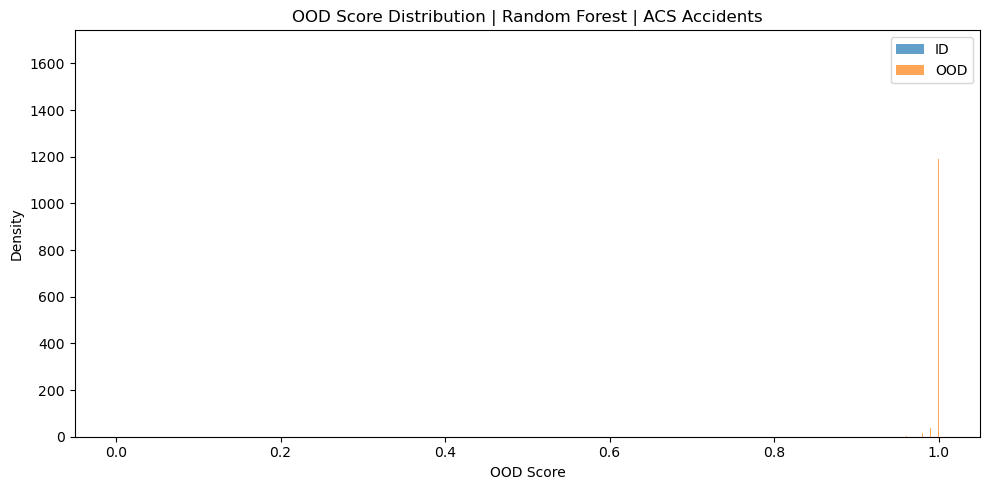


CONFUSION MATRICES


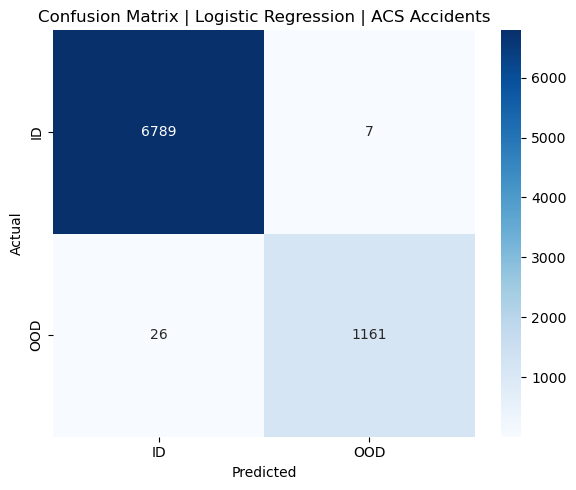

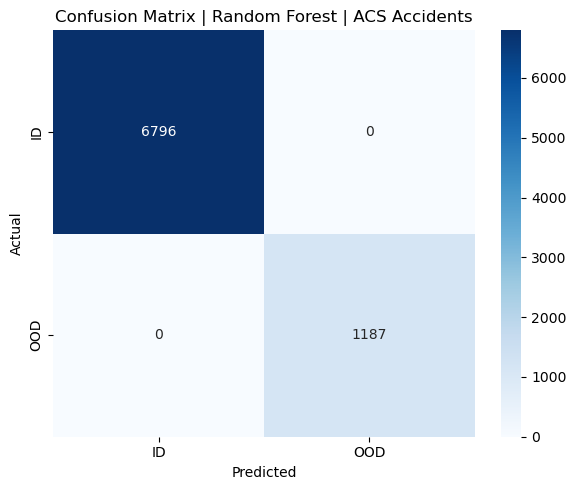

In [ ]:
res_acs = full_pipeline(
    ID_data, OOD_data,
    dataset_name='ACS Accidents',
    test_size=TEST_SIZE,
    n_bins=N_BINS,
    n_kmeans_clusters=N_KMEANS_CLUSTERS,
    n_tree_partitions=N_TREE_PARTITIONS,
    tree_max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
    use_raw_features=USE_RAW_FEATURES,
    meta_features=META_FEATURES,
    cv_folds=CV_FOLDS,
    balance_strategy=BALANCE_STRATEGY,
    include_mlp=INCLUDE_MLP,
)
summary_rows.append(('ACS Accidents', res_acs['results_df']))

---
# Results

In [ ]:
summary_data = []
for ds_name, df in summary_rows:
    for model_name in df.index:
        row = df.loc[model_name].to_dict()
        row['dataset'] = ds_name
        row['model'] = model_name
        summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df[['dataset', 'model', 'roc-auc', 'pr-auc', 'accuracy', 'precision', 'recall', 'f1-score']]
summary_df

,dataset,model,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Taxi,Logistic Regression,0.9327,0.9230,0.8755,0.8642,0.8910,0.8774
1,Taxi,Random Forest,0.9779,0.9772,0.9178,0.9228,0.9120,0.9174
2,Electricity,Logistic Regression,0.9590,0.9487,0.8905,0.8650,0.9258,0.8944
3,Electricity,Random Forest,0.9824,0.9800,0.9267,0.8964,0.9651,0.9295
4,Income,Logistic Regression,0.9294,0.8538,0.8414,0.7487,0.7693,0.7589
5,Income,Random Forest,0.9177,0.8255,0.8328,0.7381,0.7509,0.7445
6,MVx6,Logistic Regression,0.7956,0.8555,0.7838,0.9796,0.5796,0.7283
7,MVx6,Random Forest,0.7902,0.8511,0.7780,0.9409,0.5934,0.7278
8,Diabetes,Logistic Regression,0.9334,0.3525,0.9552,0.4180,0.1756,0.2473
9,Diabetes,Random Forest,0.9441,0.4003,0.9580,0.4857,0.0378,0.0701
